# Part 2 — How Do We Turn Human Preferences Into Rewards?

### The learning objective is:
### Human preference → preference data → reward model → numerical reward

## Part 2 — Learning From Human Preferences

In Part 1, our agent received a numerical reward.

For example:

Door A → 1  
Door B → 3  
Door C → 5

This made learning relatively easy.

But now consider a language model.

---

### User Prompt

> "Explain gravity to a 10-year-old."

The model generates a response.

How many points should that response receive?

**7.3?**

**4.8?**

**9.1?**

There is no simple mathematical formula that tells us
exactly how helpful a response is.

So...

> **Where can the reward come from?**

In [1]:
prompt = """
Explain gravity to a 10-year-old.
"""

response_A = """
Gravity is a fundamental interaction described by the
curvature of spacetime caused by mass and energy according
to Einstein's general theory of relativity.
"""

response_B = """
Gravity is like an invisible pull.

It is what keeps your feet on the ground and makes a ball
fall back down when you throw it into the air.

Earth is very big, so its gravity pulls things toward it.
"""

print("PROMPT:")
print(prompt)

print("\n--- RESPONSE A ---")
print(response_A)

print("\n--- RESPONSE B ---")
print(response_B)

choice = input("\nWhich response do you prefer? (A/B): ").upper()

print("\nHuman preference:", choice)

PROMPT:

Explain gravity to a 10-year-old.


--- RESPONSE A ---

Gravity is a fundamental interaction described by the
curvature of spacetime caused by mass and energy according
to Einstein's general theory of relativity.


--- RESPONSE B ---

Gravity is like an invisible pull.

It is what keeps your feet on the ground and makes a ball
fall back down when you throw it into the air.

Earth is very big, so its gravity pulls things toward it.




Which response do you prefer? (A/B):  B



Human preference: B


## So i guess you had chosen B... isnt it a preference ?

# Human Preference Data

Humans do not necessarily need to assign numerical scores.

Instead, we can ask a simpler question:

> **Which response do you prefer?**

For example:

    Response A vs Response B

Human chooses:

    ## B > A

This creates a **preference pair**.

We can collect many such comparisons:

A > B  
B > C  
D > A  
C > D  
...

Together, these comparisons form a:

## Human Preference Dataset

## We humans, we are usually much better at saying I prefer this one than deciding whether an answer deserves exactly 7.4/10.".... 

##MCQs over write the correct answer !

In [3]:
examples = [
    {
        "prompt": "Explain AI in one sentence.",
        "A": "AI refers to computational systems capable of performing tasks.",
        "B": "AI is technology that enables computers to learn, reason, and perform tasks that normally require human intelligence."
    },
    {
        "prompt": "What should I do if I forget my password?",
        "A": "Use the 'Forgot Password' option to reset it securely.",
        "B": "Passwords are used for authentication."
    },
    {
        "prompt": "Explain the Moon to a child.",
        "A": "The Moon is Earth's natural satellite with a mean radius of approximately 1,737 km.",
        "B": "The Moon is a big rocky world that travels around Earth and shines because it reflects sunlight."
    }
]

preferences = []

for i, example in enumerate(examples):

    print("\n" + "=" * 60)
    print(f"EXAMPLE {i+1}")
    print("=" * 60)

    print("\nPROMPT:")
    print(example["prompt"])

    print("\n[A]")
    print(example["A"])

    print("\n[B]")
    print(example["B"])

    choice = input("\nWhich response do you prefer? A/B: ").upper()

    preferences.append({
        "prompt": example["prompt"],
        "preferred": choice
    })

print("\nYour preferences:")
for preference in preferences:
    print(preference)


EXAMPLE 1

PROMPT:
Explain AI in one sentence.

[A]
AI refers to computational systems capable of performing tasks.

[B]
AI is technology that enables computers to learn, reason, and perform tasks that normally require human intelligence.



Which response do you prefer? A/B:  B



EXAMPLE 2

PROMPT:
What should I do if I forget my password?

[A]
Use the 'Forgot Password' option to reset it securely.

[B]
Passwords are used for authentication.



Which response do you prefer? A/B:  A



EXAMPLE 3

PROMPT:
Explain the Moon to a child.

[A]
The Moon is Earth's natural satellite with a mean radius of approximately 1,737 km.

[B]
The Moon is a big rocky world that travels around Earth and shines because it reflects sunlight.



Which response do you prefer? A/B:  B



Your preferences:
{'prompt': 'Explain AI in one sentence.', 'preferred': 'B'}
{'prompt': 'What should I do if I forget my password?', 'preferred': 'A'}
{'prompt': 'Explain the Moon to a child.', 'preferred': 'B'}


#### So this is how they had collected human feedback collection.

# What Have We Created?

We now have data that looks roughly like this:

| Prompt | Response A | Response B | Human Preference |
|---|---|---|---|
| Explain AI | Response A | Response B | B |
| Forgot password | Response A | Response B | A |
| Explain Moon | Response A | Response B | B |

The human has provided information about:

> **Which responses are preferred.**

But there is still a problem...

# "Can we have humans evaluate every response the model generates during RL training?"

# The Scaling Problem

Imagine training a language model that generates:

1,000,000 responses.

If every response needs a human to evaluate it...

we would need enormous amounts of:

- Time
- Money
- Human effort

So we need something that can **learn from human preferences**
and then estimate those preferences automatically.

That something is called a:

# REWARD MODEL

# Reward Model

Instead of asking humans forever:

                        Human Preferences
                                ↓
                                ↓
                        Learn patterns in those preferences
                                ↓
                                ↓
                           Reward Model


The Reward Model learns to answer:

> "How much would humans probably prefer this response?"

## But How Does a Reward Model Learn?

Please understand that - The reward model is not learning "the objectively correct score." It is learning to predict preferences represented in the feedback data.

# TINY REWARD MODEL

In [5]:
training_data = [
    # response, human preference score
    
    ("Clear simple explanation with an example", 1),
    ("Easy to understand and directly answers question", 1),
    ("Helpful explanation written for the user", 1),
    ("Concise answer with a useful example", 1),
    ("Simple accurate explanation", 1),

    ("Extremely complicated technical explanation", 0),
    ("Does not answer the question", 0),
    ("Confusing irrelevant response", 0),
    ("Uses unnecessary technical terminology", 0),
    ("Incorrect and unhelpful explanation", 0)
]

for text, label in training_data:
    print(label, "→", text)

1 → Clear simple explanation with an example
1 → Easy to understand and directly answers question
1 → Helpful explanation written for the user
1 → Concise answer with a useful example
1 → Simple accurate explanation
0 → Extremely complicated technical explanation
0 → Does not answer the question
0 → Confusing irrelevant response
0 → Uses unnecessary technical terminology
0 → Incorrect and unhelpful explanation


# Words to Numerical Representations!
# Problem

Machine-learning models cannot directly work with words like:
            "clear" 
            "helpful" 
            "confusing" 
            "technical"

They need numerical representations.

For this tiny experiment, we will convert text into vectors using: 
## TF-IDF
Later, modern LLM-based reward models will use learned representations instead.

In [6]:
# Training a reward model
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

texts = [text for text, label in training_data]
labels = [label for text, label in training_data]

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(texts)

reward_model = LogisticRegression()

reward_model.fit(X, labels)

print("Reward model trained!")

Reward model trained!


### We've trained a tiny model to recognize patterns associated with preferred and non-preferred responses.

## Test the Reward Model

In [7]:
new_responses = [
    "A simple explanation with a helpful example",
    "A confusing response filled with unnecessary technical terminology",
    "A clear answer that directly addresses the question"
]

X_new = vectorizer.transform(new_responses)

scores = reward_model.predict_proba(X_new)[:, 1]

for response, score in zip(new_responses, scores):
    print("\nResponse:")
    print(response)

    print(f"Reward score: {score:.3f}")


Response:
A simple explanation with a helpful example
Reward score: 0.634

Response:
A confusing response filled with unnecessary technical terminology
Reward score: 0.397

Response:
A clear answer that directly addresses the question
Reward score: 0.525


# So i guess we all have built a reward model !

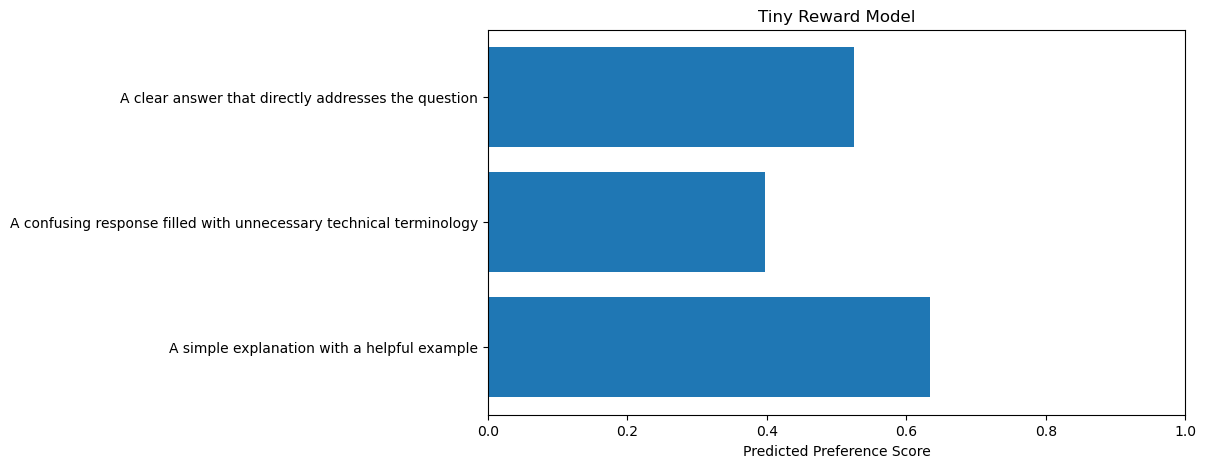

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.barh(new_responses, scores)

plt.xlabel("Predicted Preference Score")
plt.title("Tiny Reward Model")

plt.xlim(0, 1)

plt.show()

#  A More Realistic View

Suppose the model generates two responses:
    Response A  
    Response B

A human chooses:
        ## B > A

Let the reward model produce:
        r(A) = reward for A  
        r(B) = reward for B

We want the model to learn:
        ## r(B) > r(A)

In other words:
> The preferred response should receive a higher reward.

#  Turning Reward Differences Into Preference

Suppose:

    r(A) = 1.2
    r(B) = 2.8

We can estimate the probability that B is preferred using:

    P(B > A) = sigmoid(r(B) - r(A))

So the important quantity is:

    r(B) - r(A)

If B receives a much larger reward than A:

→ The model becomes more confident that B is preferred.

This allows us to train the Reward Model using human comparisons.

## This is essentially the Bradley–Terry/logistic preference formulation often used to explain reward-model training.

In [9]:
import math

def sigmoid(x):
    return 1 / (1 + math.exp(-x))


reward_A = 1.2
reward_B = 2.8

probability = sigmoid(reward_B - reward_A)

print("Reward A:", reward_A)
print("Reward B:", reward_B)

print(
    "\nProbability that humans prefer B:",
    round(probability, 3)
)

Reward A: 1.2
Reward B: 2.8

Probability that humans prefer B: 0.832


In [ ]:
# Try it out !

reward_A = 4
reward_B = 1

print(sigmoid(reward_B - reward_A))

#  What Have We Built So Far?

We started with:

## Step 1 — Prompt

"Explain gravity to a child."

                ↓

## Step 2 — Generate multiple responses

Response A

Response B

                ↓

## Step 3 — Human comparison

Human says:

B > A

                ↓

## Step 4 — Collect many preferences

Preference Dataset

                ↓

## Step 5 — Train a Reward Model

The Reward Model learns patterns in human preferences.

                ↓

## Step 6 — Score new responses

Prompt + Response
        
                ↓

Reward Model

                ↓

Numerical Reward

#  Remember Part 1?

In our Door Experiment:

Agent → chooses Door → Environment → Reward

Now compare that with language:

LLM → generates Response → Reward Model → Reward


The basic Reinforcement Learning idea has not disappeared.

What changed?

## Where the reward came from.


# RLHF 
                    HUMAN
                       │
                       ▼
              Preference Data
                       │
                       ▼
                 Reward Model
                       │
                       ▼
LLM → Response ─────► Reward


# So always remember the reward model comes from human Feedback!

# Challenge

A language model produces two responses.

Human preference:

        Response B > Response A

The Reward Model currently predicts:
            
            r(A) = 4.2
            r(B) = 1.8

### Questions

1. Is the Reward Model behaving correctly?
2. Which response should receive the larger reward?
3. During Reward Model training, what should we try to change?
4. Are humans required to score every future response?

In [ ]:
1. No.
2. B should receive the larger reward.
3. Increase the relative reward of B compared with A.
4. No. Once trained, the Reward Model can estimate
   rewards for new responses

#  We Have a Reward Model!

Our system can now do this:

                    Prompt
                       ↓
                    LLM
                       ↓
                    Response
                       ↓
                    Reward Model
                       ↓
                    Reward = 0.82

Great!

But...

## What do we actually DO with that reward?

Suppose:
                
                Response A → Reward = 0.23
                
                Response B → Reward = 0.91

How does the LLM learn:

> "Generate more responses like B"?

How do we change the model itself?

In [ ]:
               ┌───────────────┐
Prompt ───────►│      LLM      │
               │    POLICY     │
               └───────┬───────┘
                       │
                    Response
                       │
                       ▼
               ┌───────────────┐
               │ REWARD MODEL  │◄──── Human
               └───────┬───────┘      Preferences
                       │
                     Reward
                       │
                       ▼
                   ?????????
                       │
                       │ UPDATE
                       ▼
                      LLM